# MaxEnt IRL Driving Simulation Pipeline

This notebook performs the complete workflow for a driving behavior imitation learning pipeline:

- Preprocess raw trajectory data
- Build trajectory sequences
- Construct the MDP representation
- Train a Maximum Entropy Inverse Reinforcement Learning (MaxEnt IRL) model
- Evaluate the learned policy
- Save artifacts for visualization and later analysis
- Visualisation of graphs
- Simulation in highway-env, python gymnasium 


The code is divided into steps, skip steps 1 - 10 if Agent is already trained (irl_artifacts.pkl exists)

In [16]:

# Imports

# Custom project modules
import preprocess as pp
import build_trajectories2 as build
import DrivEnv as env
import maxEntIRL as me
import MDPBuilder as mdp

# Standard libraries
import os
import random
import pickle

# Data science libraries
import pandas as pd
import numpy as np

## Step 1 — Define File Paths

These paths define:
- The raw driving dataset
- The preprocessed dataset output
- The generated trajectory dataset


In [17]:
# Raw dataset path
raw_data_path = r"data\M40-d07-h08.dat"

# Preprocessed CSV output
preprocessed_output_path = r"data\dataset.csv"

# Generated trajectories output
trajectories_output_path = r"data\M40_d07_h08_trajectories_updated.csv"

## Step 2 — Preprocess Raw Data

This step converts the raw `.dat` traffic dataset into a cleaned CSV format suitable for trajectory extraction.

> Uncomment the preprocessing line if preprocessing has not been done yet.


In [ ]:

# Preprocess the raw traffic data


# Uncomment this line if dataset.csv does not already exist
#pp.Preprocess(raw_data_path, preprocessed_output_path)

print("Preprocessing step completed.")

Initial unclean data percentage: 0.0%
Unclean data percentage after motion features: 0.7772311257961817%
Unclean data percentage after additional features: 0.0%
Preprocessing step completed.


## Step 3 — Build Trajectories

This step converts the preprocessed dataset into trajectory sequences that can be used by the MDP and IRL pipeline.


In [6]:

# Build trajectories from preprocessed data


builder = build.BuildTrajectories(
    preprocessed_output_path,
    trajectories_output_path
)

# Generate trajectory dataframe
trajectories_df = builder.run(trajectories_output_path)

# Uncomment if Alternative: Load directly if trajectories already exist
# trajectories_df = pd.read_csv(trajectories_output_path)

print("Trajectory generation completed.")
print(f"Number of rows: {len(trajectories_df)}")


Total trajectories created: 160

All selected vehicles have 8 trajectories each.


Saved trajectories to data\M40_d07_h08_trajectories_updated.csv

Trajectory generation completed.
Number of rows: 16000


## Step 4 — Create the Environment and Build the MDP

Here we:
- Create the driving environment
- Build the Markov Decision Process (MDP)
- Generate transition matrices and feature representations


In [7]:

# Create driving environment


env_instance = env.DrivingEnv(trajectories_df)


# Build the MDP


mdp_builder = mdp.MDPBuilder(trajectories_df)
mdp_data = mdp_builder.build_all()

print("MDP construction completed.")
print(f"Number of states: {mdp_data['n_states']}")
print(f"Number of actions: {mdp_data['n_actions']}")

1. Initializing MDP with 1512 discrete states...
2. Extracting and discretizing expert trajectories...
3. Building Feature Matrix phi(s)...
4. Calculating Initial State Distribution and Horizon...
5. Building deterministic Transition Matrix P(s'|s,a)
MDP Build Complete.
MDP construction completed.
Number of states: 1512
Number of actions: 15


## Step 5 — Train/Test Split

We split the expert trajectories into:
- 80% training data
- 20% testing data

The split is randomized using a fixed seed for reproducibility.


In [8]:

# Train/Test Split


all_trajectories = mdp_data["expert_trajectories"]

# Shuffle for random distribution
random.seed(42)
random.shuffle(all_trajectories)

# 80/20 split
split_idx = int(0.8 * len(all_trajectories))

train_trajectories = all_trajectories[:split_idx]
test_trajectories = all_trajectories[split_idx:]

print(f"Data Split: {len(train_trajectories)} Train | {len(test_trajectories)} Test")

# Recompute initial state distribution and horizon for training set
initial_dist, train_horizon = mdp_builder.get_initial_dist_and_horizon(train_trajectories)

print(f"Training Horizon: {train_horizon}")

Data Split: 128 Train | 32 Test
Training Horizon: 99


## Step 6 — Initialize and Train the MaxEnt IRL Agent

The Maximum Entropy Inverse Reinforcement Learning algorithm learns a reward function from expert demonstrations.

Inputs include:
- Transition probabilities
- Feature matrix
- Initial state distribution
- Expert trajectories


Initializing MaxEnt IRL...
Starting MaxEnt IRL Training Loop...
Iteration 0 | Gradient Norm: 90.1765
Iteration 10 | Gradient Norm: 15.1931
Iteration 20 | Gradient Norm: 8.8247
Iteration 30 | Gradient Norm: 7.3658
Iteration 40 | Gradient Norm: 6.7622
Iteration 50 | Gradient Norm: 6.4587
Iteration 59 | Gradient Norm: 6.2986


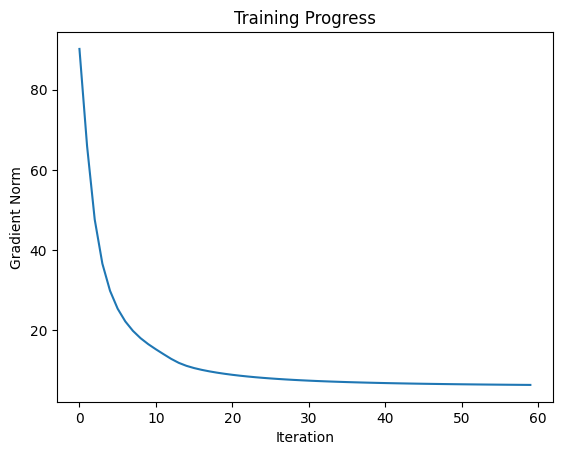

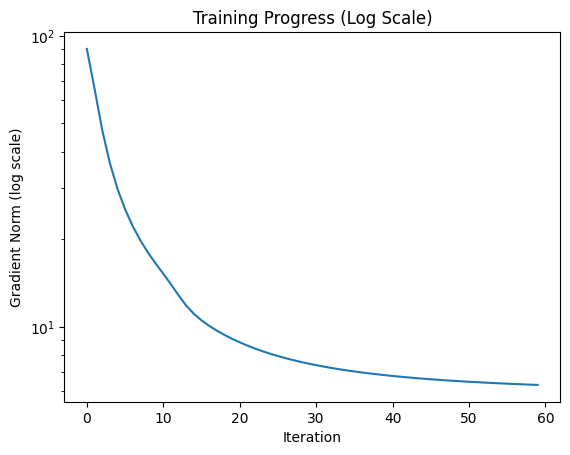

Training completed.
Learned Reward Weights:
[ -0.01043589  -3.30593768  -4.74524362  -4.64128982  -1.12573383
 -10.          -1.81790528]


In [9]:

# Initialize MaxEnt IRL Agent


print("Initializing MaxEnt IRL...")

irl_agent = me.MaxEntIRL(
    n_states=mdp_data["n_states"],
    n_actions=mdp_data["n_actions"],
    transition_probs=mdp_data["transition_matrix"],
    feature_matrix=mdp_data["feature_matrix"],
    initial_state_dist=initial_dist,
    horizon=train_horizon,
    learning_rate=0.01
)

print("Starting MaxEnt IRL Training Loop...")

# Remove trajectory IDs before training
just_train_trajs = [traj for traj_id, traj in train_trajectories]

# Train the IRL model
learned_theta, learned_policy = irl_agent.train(
    expert_trajectories=just_train_trajs,
    iterations=60
)

print("Training completed.")
print("Learned Reward Weights:")
print(learned_theta)

## Step 7 — Save Artifacts for Visualization

This section saves:
- Expert trajectories
- Simulated trajectories
- Learned reward parameters
- Policy and MDP artifacts

These outputs can later be used for plotting and visualization.


In [10]:

# Create results directory


os.makedirs("results", exist_ok=True)

print("Results directory ready.")

Results directory ready.


## Step 8 — Generate Sample Expert and Simulated Trajectories

We select one test trajectory and generate:
- The expert trajectory
- A simulated trajectory from the learned policy

These will be saved as CSV files for analysis.


In [11]:

# Generate sample trajectories for visualization


# Select a sample trajectory from the test set
sample_traj_id, sample_expert_traj = test_trajectories[0]

# Determine trajectory horizon
horizon = len(sample_expert_traj)

# Extract expert trajectory dataframe
sample_expert_df = env_instance.data[
    env_instance.data["traj_id"] == sample_traj_id
].head(horizon).reset_index(drop=True)

# Simulate trajectory using learned policy
sample_sim_df = env_instance.simulate_agent(
    mdp_builder,
    learned_policy,
    sample_traj_id,
    max_steps=horizon
)

print("Sample trajectories generated.")

Sample trajectories generated.


## Step 9 — Save CSV Outputs

Save the expert and simulated trajectories for easy inspection and visualization.


In [12]:

# Save trajectory CSV files


sample_expert_df.to_csv("results/expert_trajectory.csv", index=False)
sample_sim_df.to_csv("results/simulated_trajectory.csv", index=False)

print("Trajectory CSV files saved.")

Trajectory CSV files saved.


## Step 10 — Save Model Artifacts

Store all important training artifacts in a pickle file.

Saved contents:
- Learned reward weights (`theta`)
- Learned policy
- MDP data
- Test trajectories


In [13]:

# Save artifacts using pickle


artifacts = {
    "theta": learned_theta,
    "policy": learned_policy,
    "mdp_data": mdp_data,
    "test_trajectories": test_trajectories
}

with open("results/irl_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("All artifacts saved successfully in the 'results/' folder.")

All artifacts saved successfully in the 'results/' folder.


## Step 11 — Evaluate the Learned Policy

We now evaluate the learned policy using the test trajectories.

The environment compares the simulated behavior against expert demonstrations.


In [14]:

# Evaluate learned policy


print("Starting Simulation & Evaluation on Test Set...")

env_instance.evaluate_performance(
    mdp_builder=mdp_builder,
    policy=learned_policy,
    test_trajectories=test_trajectories
)

print("Evaluation completed.")

Starting Simulation & Evaluation on Test Set...
Evaluating 32 test trajectories

EVALUATION RESULTS
Average Velocity RMSE: 2.16 m/s
Average X-Position RMSE: 44.36 meters
Average Y-Position RMSE: 1.75 meters
Average FEE: 1.74
Average FEE Breakdown by Feature:
  - v: 0.4367
  - accel: 0.0088
  - lat_accel: -0.3179
  - jerk: -0.1034
  - front_risk: 0.0000
  - collision: -0.0290
  - interaction: -0.0088
Evaluation completed.


# Visualization Pipeline

This section loads the saved artifacts and visualizes:

- Expert trajectories
- Simulated trajectories
- Learned reward behavior
- Policy behavior
- Experiment 2 style comparisons (optional)


In [15]:
import pickle
import pandas as pd
import Visualiser as vis
import numpy as np
import os

Toggle between Visualise ouput of Experiment 2 or not

In [18]:
# Toggle between:
# False -> Standard IRL visualization
# True  -> Experiment 2 style comparison visualization
experiment2 = False

Loading saved artifacts...
Trajectory CSV files loaded successfully.
IRL artifacts loaded successfully.
Visualizer initialized.
Visualizing Trajectories...


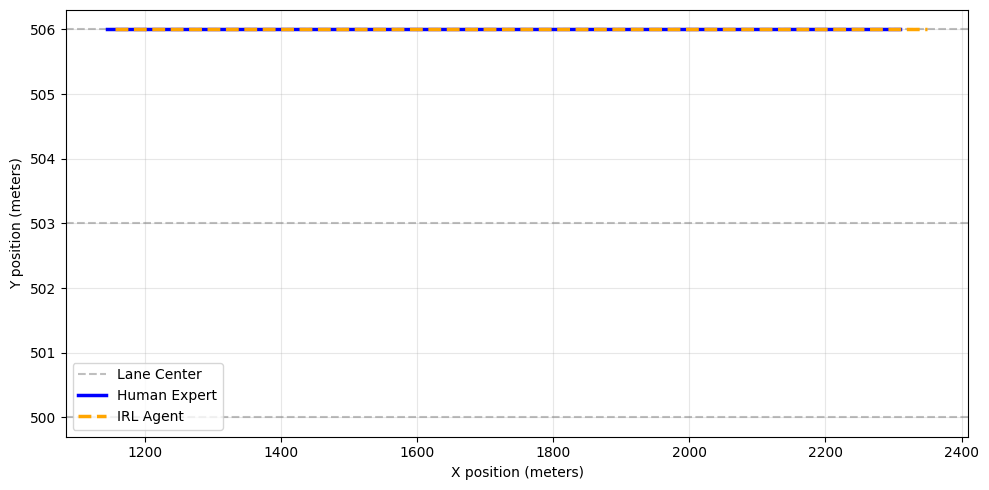

Visualizing Kinematics Over Time...


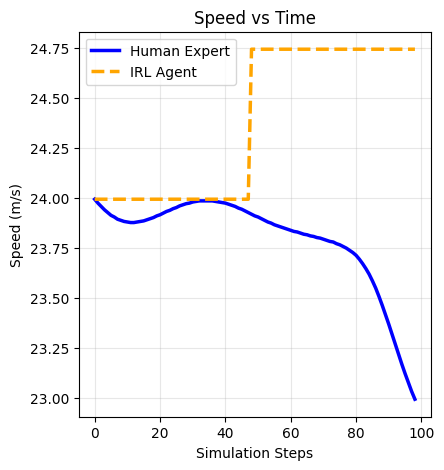

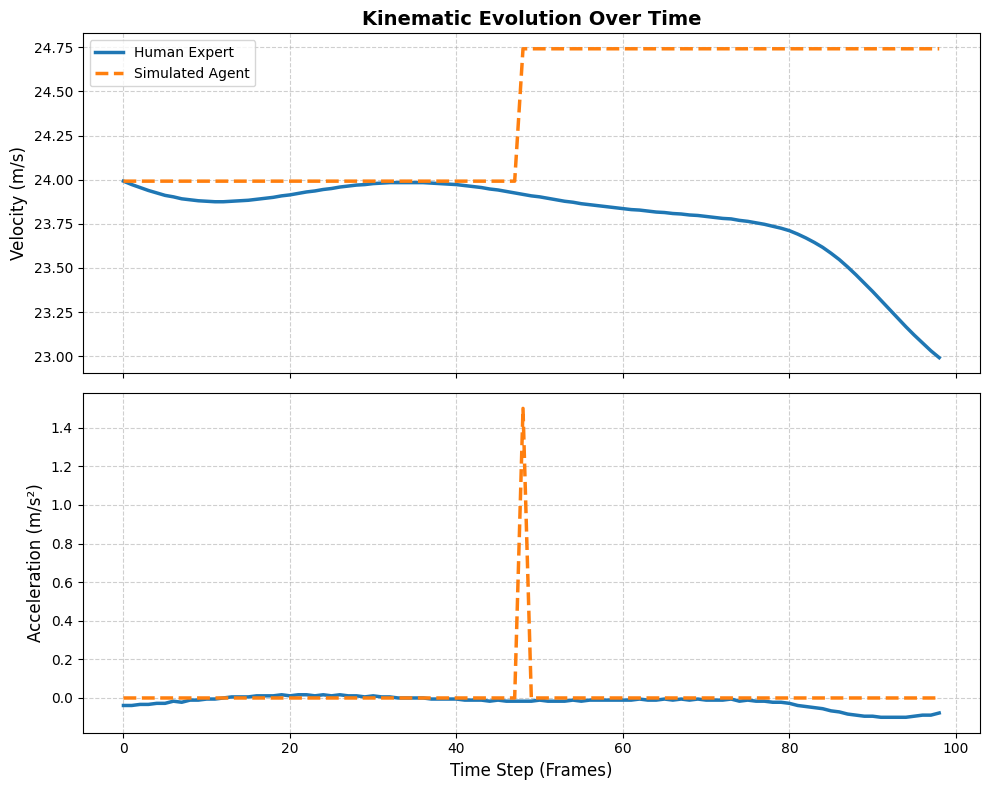

Visualizing Reward Weights...


c:\Users\omkar\Desktop\TFG\TFG_IL\Visualiser.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=self.feature_names, y=self.theta, palette=colors)


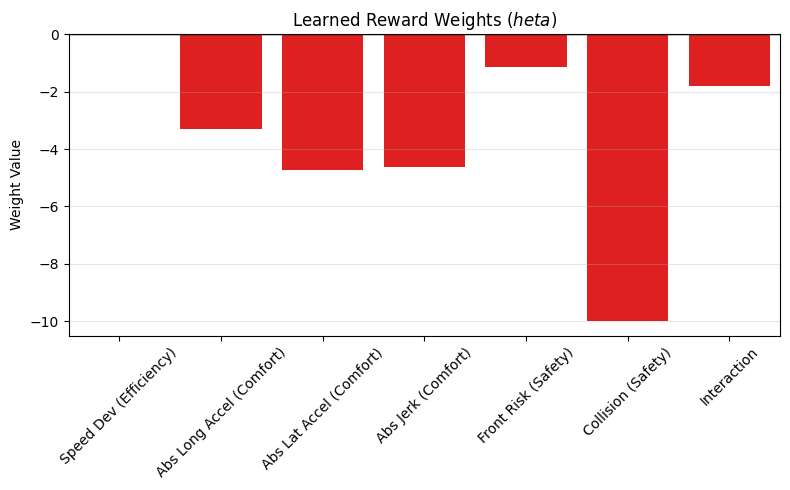

Visualizing Action Distributions...


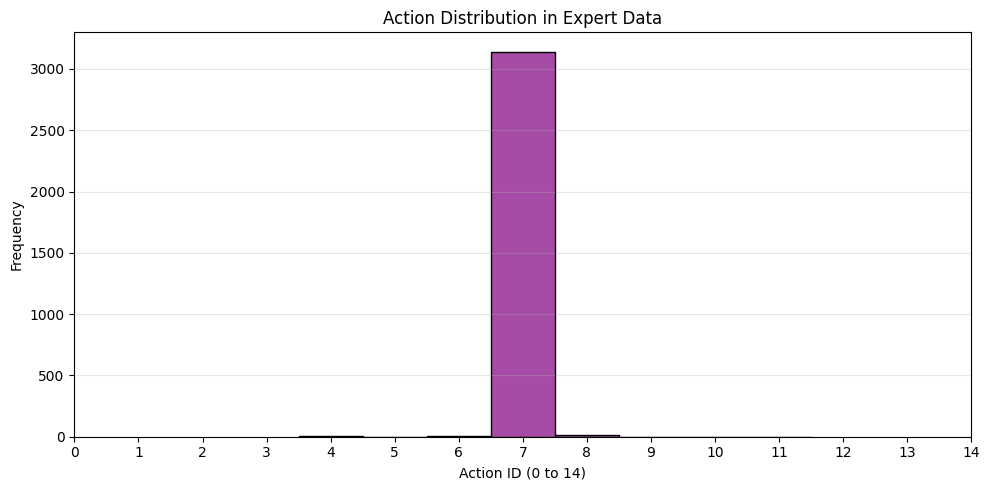

Visualizing Feature Expectation Matching...


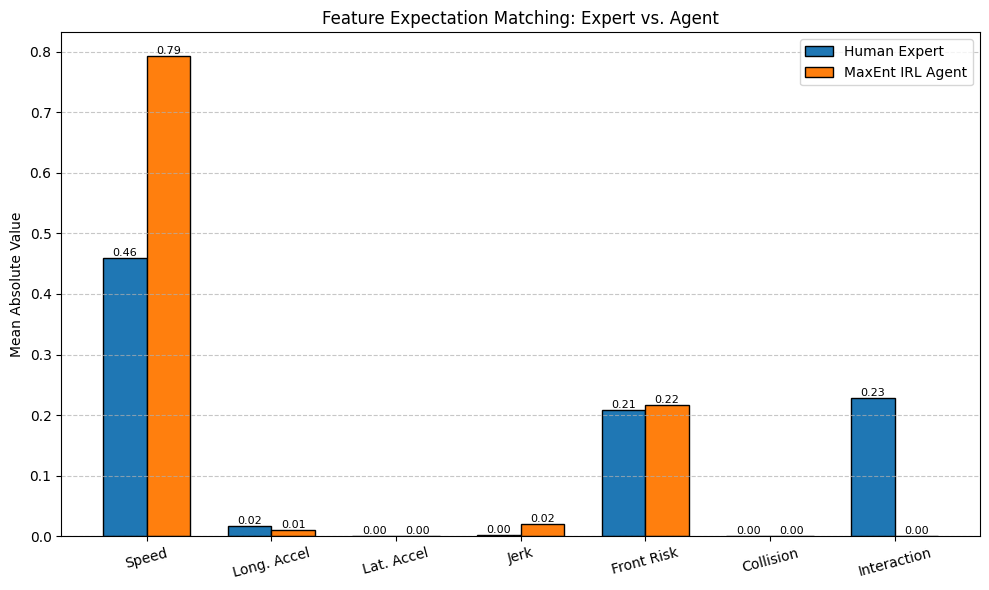

Visualization pipeline completed successfully.


In [19]:

# Visualization Main Execution Block

# Directory where all saved outputs are stored
results_dir = "results"

print("Loading saved artifacts...")


# Experiment 2 Visualization Mode


if experiment2:
    print("Running Experiment 2 Visualizations...")

    # Import aggregated and conservative driving styles
    # along with policies and expert demonstrations
    agg_sim, cons_sim, visualizer, agg_policy, cons_policy, agg_exp, cons_exp = vis.import_data_for_styles()

    # Optional: Run full visualization pipeline
    # visualizer.run_all(
    #     expert_df=agg_sim,
    #     simulated_df=cons_sim,
    #     test_trajectories=0,
    #     policy=agg_policy,
    #     experiment2=True
    # )

    # Plot comparison between aggressive and conservative styles
    visualizer.plot_style_comparison(
        agg_sim,
        cons_sim,
        agg_exp,
        cons_exp
    )


# Standard Visualization Mode


else:

    try:
        
        # Load saved trajectory CSV files
        

        expert_df = pd.read_csv(f"{results_dir}/expert_trajectory.csv")
        sim_df = pd.read_csv(f"{results_dir}/simulated_trajectory.csv")

        print("Trajectory CSV files loaded successfully.")

        
        # Load saved IRL artifacts
        

        with open(f"{results_dir}/irl_artifacts.pkl", "rb") as f:
            artifacts = pickle.load(f)

        print("IRL artifacts loaded successfully.")

        
        # Extract stored objects
        

        theta = artifacts["theta"]
        mdp_data = artifacts["mdp_data"]
        test_trajectories = artifacts["test_trajectories"]

        # Policy may not exist in older artifact files
        policy = artifacts.get("policy", None)

        
        # Initialize the visualizer

        visualizer = vis.IRLVisualizer(
            mdp_data=mdp_data,
            theta=theta
        )

        print("Visualizer initialized.")

        
        # Run the visualization pipeline
        

        visualizer.run_all(
            expert_df=expert_df,
            simulated_df=sim_df,
            test_trajectories=test_trajectories,
            policy=policy,
            experiment2=False
        )

        print("Visualization pipeline completed successfully.")

    except FileNotFoundError:
        print("Error: Could not find the saved files.")
        print("Make sure the training notebook has been executed first.")

# Highway Environment IRL Simulation

This notebook section runs the trained MaxEnt IRL policy inside the `highway-env` simulator.
This notebook version can only show final statistics, to see simulator visually, run "main" in Simulator.py class.

The simulator:
- Loads trained IRL policies
- Simulates driving episodes
- Compares behavior against expert trajectories
- Computes driving statistics
- Saves evaluation metrics for later analysis

Metrics collected:
- Average speed
- Number of lane changes
- Crash count


 Necessary imports for simulation

In [20]:
import pickle
import pandas as pd
import numpy as np
import time
import Simulator as simHigh
from highway_env.vehicle.kinematics import Vehicle


Load artifacts and initialise

In [21]:

# Main Simulation Execution
# Load Style Artifacts


with open("results/styles_artifacts.pkl", "rb") as f:
    styles = pickle.load(f)

# Aggressive driving profile
agg_mdp_data = styles["aggressive"]["mdp_data"]
agg_policy = styles["aggressive"]["policy"]

# Conservative driving profile
cons_mdp_data = styles["conservative"]["mdp_data"]
cons_policy = styles["conservative"]["policy"]


# Load Default IRL Artifacts


print("Loading IRL Artifacts and Expert Data...")
try:
    with open("results/irl_artifacts.pkl", "rb") as f:
        artifacts = pickle.load(f)
            
        mdp_data = artifacts["mdp_data"]
        policy = artifacts["policy"]
        expert_df = pd.read_csv("results/expert_trajectory.csv")
        
except FileNotFoundError:
    print(" Error: Missing files in 'results/' folder.")
    exit()

print("Initializing Unified Simulator...")
sim = simHigh.IntegratedHighwaySimulator(mdp_data=mdp_data, render=True)
    
expert_start_x = expert_df.iloc[0]['x']
expert_start_y = expert_df.iloc[0]['y']
expert_start_v = expert_df.iloc[0]['computed_v']


# M40: 500, 503, 506 (Ancho de 3m) -> Índices: 0, 1, 2 -> Highway-Env: 0, 4, 8 (Ancho de 4m)
def normalize_y(y_real):
    
    lane_idx = round((y_real - 500.0) / 3.0)
    
    lane_idx = max(0, min(2, lane_idx)) 
    return lane_idx * 4.0
sim_start_y = normalize_y(expert_start_y)

sim.env.unwrapped.vehicle.position = np.array([0.0, sim_start_y])
sim.env.unwrapped.vehicle.speed = expert_start_v

Loading IRL Artifacts and Expert Data...
Initializing Unified Simulator...


In [ ]:
# Only run to compare with expert trajectory

ghost_car = Vehicle(
    road=sim.env.unwrapped.road, 
    position=[10.0, sim_start_y], 
    speed=expert_start_v
)
ghost_car.color = (255, 0, 255) # Magenta
ghost_car.crashed = False 
#sim.env.unwrapped.road.vehicles.append(ghost_car)

print("\n--- Starting Ghost Car Comparison (Shadow Mode) ---")
sim.env.unwrapped.road.vehicles.append(ghost_car)


--- Starting Ghost Car Comparison (Shadow Mode) ---


Run episode

In [ ]:
# Episode Rollout
state_idx = sim.reset()
done = truncated = False
step_count = 0
speed = 0
while not truncated and not done:
    # Ask IRL Agent for Action
    action_probs = policy[state_idx]
    prob_sum = np.sum(action_probs)
    #if prob_sum > 0:
    #    action_probs = action_probs / prob_sum
    #else:
    #    # PROFESSIONAL FALLBACK: Maintain current trajectory rather than panicking arbitrarily
    #    action_probs = np.zeros(len(action_probs))
    #    idle_action_idx = sim.physical_actions.index((0.0, 0)) # Find the (0 delta_v, 0 delta_lane) action
    #    action_probs[idle_action_idx] = 1.0
    action_idx = np.random.choice(len(action_probs), p=action_probs)
    #print(f"Step {step_count}: State {state_idx} -> Action {action_idx}: {sim.physical_actions[action_idx]} (Action Probabilities: {action_probs})")
    
    # Step Simulator
    next_state_idx, reward, done, truncated, info = sim.step(action_idx)
    
    sim.env.unwrapped.vehicle.crashed = False
    ghost_car.crashed = False
    
    if step_count < len(expert_df):
        historical_data = expert_df.iloc[step_count]
        
        # Avanzar X relativo al punto de partida original
        normalized_x = historical_data['x'] - expert_start_x
        # Calcular Y con nuestra nueva función de carriles
        normalized_y = normalize_y(historical_data['y'])
        
        #ghost_car.position = np.array([normalized_x, normalized_y])
        #ghost_car.speed = historical_data['computed_v']
        
    speed += sim.env.unwrapped.vehicle.speed

    sim.render()
    time.sleep(0.1) 
    
    state_idx = next_state_idx
    step_count += 1

# Episode Statistics

speed /= step_count if step_count > 0 else 1.0
sim.close()


# Final Statistics
print("Simulation Episode Completed.")
print(f"Total Steps: {step_count}")
print(f"Average Speed: {speed:.2f} m/s")
print("\nSimulation Complete")


## Hypothesis Testing Results
Simulation of 50 episodes has already been ran and saved in /results, next code demonstrates the p-values calculation from those files.

First Visualise results of Experiment 2 with overall metrics

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data from CSVs
agg_df = pd.read_csv("results/simulation_results_agg.csv")
cons_df = pd.read_csv("results/simulation_results_cons.csv")
control_df = pd.read_csv("results/simulation_results_control.csv")

# Compute metrics dynamically from the datasets
df = pd.DataFrame({
    "Behavior": ["Control", "Aggressive", "Conservative"],

    # Mean average speed
    "Average Speed": [
        control_df["Average_Speed"].mean(),
        agg_df["Average_Speed"].mean(),
        cons_df["Average_Speed"].mean()
    ],

    # Total / mean lane changes (choose one)
    "Lane Changes": [
        control_df["Lane_Changes"].sum(),
        agg_df["Lane_Changes"].sum(),
        cons_df["Lane_Changes"].sum()
    ],

    # Crash counts
    "Crashes": [
        control_df["Crashes"].iloc[0],
        agg_df["Crashes"].iloc[0],
        cons_df["Crashes"].iloc[0]
    ]
})

# Convert to long format
df_melted = df.melt(
    id_vars="Behavior",
    var_name="Metric",
    value_name="Value"
)

# Thesis-style theme
sns.set_theme(style="whitegrid", font_scale=1.2)

# Custom colors
custom_palette = {
    "Control": "#1408f0",        # Blue
    "Aggressive": "#e51c1c",    # Red
    "Conservative": "#2dcf2d"   # Green
}

# Create figure
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=df_melted,
    x="Metric",
    y="Value",
    hue="Behavior",
    palette=custom_palette
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# Labels
plt.xlabel("")
plt.ylabel("Measured Value", fontsize=13)

# Legend formatting
plt.legend(
    title="Behavior Type",
    frameon=True
)

# Remove unnecessary borders
sns.despine()

# Tight layout
plt.tight_layout()

# Save figure
#plt.savefig(
#    r"C:\Users\omkar\Desktop\TFG\graphs\driving_behavior_comparison.png",
#    dpi=300,
#    bbox_inches='tight'
#)

# Show plot
plt.show()

Compute p-values pairwise:

In [39]:
from scipy import stats
import pandas as pd
import numpy as np
from itertools import combinations

# Load CSVs
agg_df = pd.read_csv("results/simulation_results_agg.csv")
cons_df = pd.read_csv("results/simulation_results_cons.csv")
control_df = pd.read_csv("results/simulation_results_control.csv")

# Store all behaviours in a dictionary
behaviours = {
    "AGGRESSIVE": agg_df,
    "CONSERVATIVE": cons_df,
    "CONTROL": control_df
}

alpha = 0.05
episodes = 50  # total simulation episodes


def interpret_pvalue(metric_name, p_value):
    """Print interpretation of hypothesis test."""
    print(f"{metric_name} p-value: {p_value:.5f}")

    if p_value < alpha:
        print(f"→ Significant difference in {metric_name.lower()} (Reject H0)")
    else:
        print(f"→ No significant difference in {metric_name.lower()} (Fail to reject H0)")


def compare_behaviours(name1, df1, name2, df2):
    print("\n" + " " * 60)
    print(f"{name1} vs {name2}")
    #print("=" * 60)

    # Extract metrics
    speeds1 = df1["Average_Speed"].tolist()
    speeds2 = df2["Average_Speed"].tolist()

    lane1 = df1["Lane_Changes"].tolist()
    lane2 = df2["Lane_Changes"].tolist()

    crashes1 = df1["Crashes"].iloc[0]
    crashes2 = df2["Crashes"].iloc[0]

    
    # Speed T-Test
    
    t_speed, p_speed = stats.ttest_ind(speeds1, speeds2)

    print("\n[Average Speed]")
    interpret_pvalue("Speed", p_speed)

    
    # Lane Change T-Test
    
    t_lane, p_lane = stats.ttest_ind(lane1, lane2)

    print("\n[Lane Changes]")
    interpret_pvalue("Lane Changes", p_lane)

    
    # Crash Chi-Square Test
    
    contingency_table = np.array([
        [crashes1, episodes - crashes1],
        [crashes2, episodes - crashes2]
    ])

    chi2, p_crash, dof, expected = stats.chi2_contingency(contingency_table)

    print("\n[Crashes]")
    interpret_pvalue("Crash Rate", p_crash)

    
    # Summary Statistics
    
    print("\n[Summary Statistics]")
    print(f"{name1} Mean Speed: {np.mean(speeds1):.2f}")
    print(f"{name2} Mean Speed: {np.mean(speeds2):.2f}")

    print(f"{name1} Mean Lane Changes: {np.mean(lane1):.2f}")
    print(f"{name2} Mean Lane Changes: {np.mean(lane2):.2f}")

    print(f"{name1} Crashes: {crashes1}")
    print(f"{name2} Crashes: {crashes2}")


# Main
if __name__ == "__main__":

    # Generate all pairwise comparisons
    for (name1, df1), (name2, df2) in combinations(behaviours.items(), 2):
        compare_behaviours(name1, df1, name2, df2)


                                                            
AGGRESSIVE vs CONSERVATIVE

[Average Speed]
Speed p-value: 0.00005
→ Significant difference in speed (Reject H0)

[Lane Changes]
Lane Changes p-value: 0.43178
→ No significant difference in lane changes (Fail to reject H0)

[Crashes]
Crash Rate p-value: 0.00161
→ Significant difference in crash rate (Reject H0)

[Summary Statistics]
AGGRESSIVE Mean Speed: 23.52
CONSERVATIVE Mean Speed: 19.63
AGGRESSIVE Mean Lane Changes: 1.32
CONSERVATIVE Mean Lane Changes: 1.50
AGGRESSIVE Crashes: 21
CONSERVATIVE Crashes: 6

                                                            
AGGRESSIVE vs CONTROL

[Average Speed]
Speed p-value: 0.25492
→ No significant difference in speed (Fail to reject H0)

[Lane Changes]
Lane Changes p-value: 0.14267
→ No significant difference in lane changes (Fail to reject H0)

[Crashes]
Crash Rate p-value: 0.68177
→ No significant difference in crash rate (Fail to reject H0)

[Summary Statistics]
AGGRESSIVE

In [ ]:
# AGGRESSIVE vs CONSERVATIVE Chi-squared with results for Collisions

# T-Test (Speed)
t_statistic = 4.25
p_value_t = 0.00005

# T-Test (Lane Changes)
t_statistic_lane = 0.79
p_value_lane = 0.43178

# Chi-Square Test (Crashes)
chi_statistic = 9.95
p_value_chi = 0.00161

C:\Users\omkar\AppData\Local\Temp\ipykernel_4188\1260720452.py:70: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


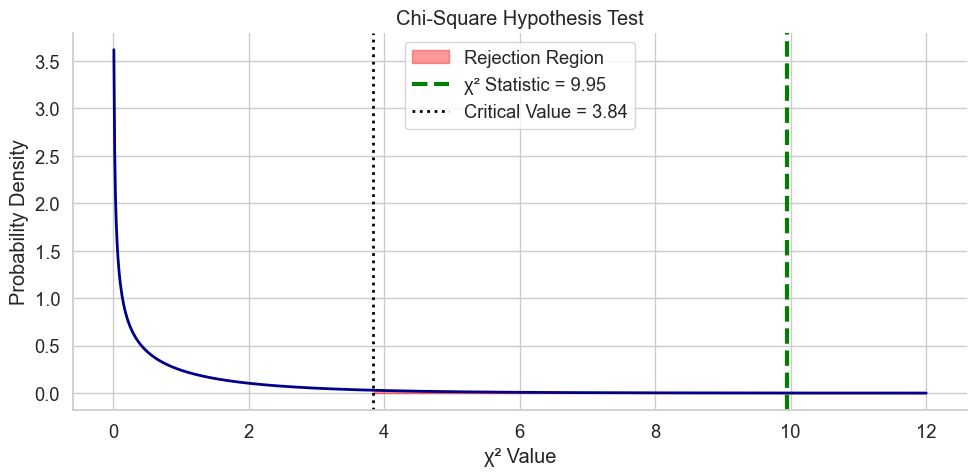

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2
import seaborn as sns


sns.set_theme(style="whitegrid", font_scale=1.2)

alpha = 0.05

# CHI-SQUARE TEST VISUALISATION (RIGHT-TAILED)
dof = 1

# Critical chi-square value
chi_critical = chi2.ppf(1 - alpha, dof)

x = np.linspace(0, 12, 1000)
y = chi2.pdf(x, dof)

plt.figure(figsize=(10, 5))

# Chi-square distribution
plt.plot(x, y, color='darkblue', linewidth=2)

# Shade rejection region
plt.fill_between(
    x, y,
    where=(x >= chi_critical),
    color='red',
    alpha=0.4,
    label='Rejection Region'
)

# Test statistic
plt.axvline(
    chi_statistic,
    color='green',
    linestyle='--',
    linewidth=3,
    label=f'χ² Statistic = {chi_statistic:.2f}'
)

# Critical value
plt.axvline(
    chi_critical,
    color='black',
    linestyle=':',
    linewidth=2,
    label=f'Critical Value = {chi_critical:.2f}'
)

# Labels
plt.title("Chi-Square Hypothesis Test")
plt.xlabel("χ² Value")
plt.ylabel("Probability Density")

# Interpretation
decision = "Reject H₀" if p_value_chi < alpha else "Fail to Reject H₀"

plt.text(
    chi_statistic,
    max(y) * 0.75,
    f"p-value = {p_value_chi:.3f}\nα = {alpha}\n{decision}",
    fontsize=12,
    bbox=dict(facecolor='white', edgecolor='black')
)

plt.legend()
sns.despine()
plt.tight_layout()
plt.show()